In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [3]:
from google.colab import files

# Upload the housing.csv file
print("Please upload the 'housing.csv' file:")
uploaded = files.upload()

Please upload the 'housing.csv' file:


Saving business-financial-data-september-2025-quarter.csv to business-financial-data-september-2025-quarter.csv


In [5]:
housing = pd.read_csv("business-financial-data-september-2025-quarter.csv")

print("First 5 rows")
print(housing.head())

print("\nInfo of dataset")
print(housing.info())

print("\nDescription of dataset")
print(housing.describe())

First 5 rows
  Series_reference   Period  Data_value Suppressed STATUS    UNITS  Magnitude  \
0    BDCQ.SF1AA2CA  2016.06    1116.386        NaN      F  Dollars          6   
1    BDCQ.SF1AA2CA  2016.09    1070.874        NaN      F  Dollars          6   
2    BDCQ.SF1AA2CA  2016.12    1054.408        NaN      F  Dollars          6   
3    BDCQ.SF1AA2CA  2017.03    1010.665        NaN      F  Dollars          6   
4    BDCQ.SF1AA2CA  2017.06    1233.700        NaN      F  Dollars          6   

                          Subject  \
0  Business Data Collection - BDC   
1  Business Data Collection - BDC   
2  Business Data Collection - BDC   
3  Business Data Collection - BDC   
4  Business Data Collection - BDC   

                                             Group            Series_title_1  \
0  Industry by financial variable (NZSIOC Level 2)  Sales (operating income)   
1  Industry by financial variable (NZSIOC Level 2)  Sales (operating income)   
2  Industry by financial variable (NZ

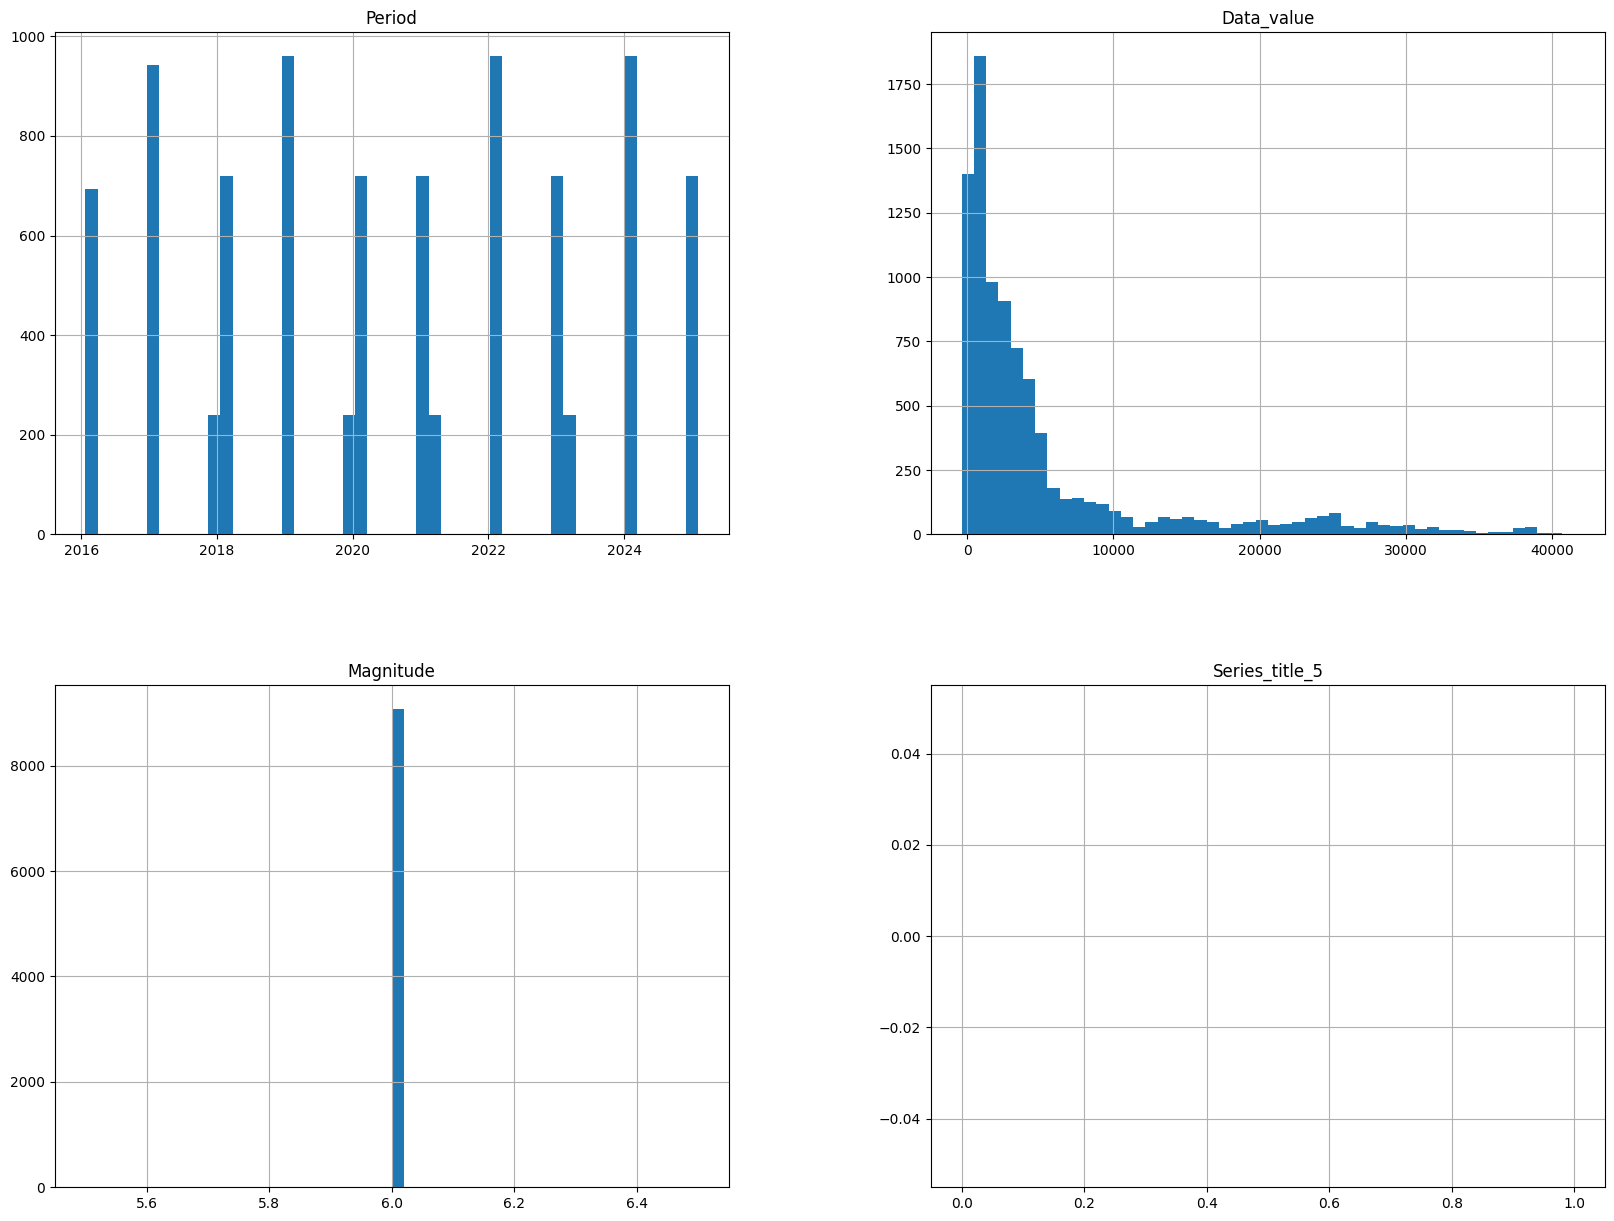

In [6]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [7]:
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print("Train size:",len(train_set))
print("Test size:",len(test_set))

Train size: 7260
Test size: 1815


In [11]:
housing.dropna(subset=["Data_value"], inplace=True)
# Reset index after dropping rows to ensure a clean, contiguous integer index
housing.reset_index(drop=True, inplace=True)
housing["data_value_cat"] = pd.qcut(housing["Data_value"], q=5, labels=False, duplicates='drop')
# Add 1 to the labels to make them 1-5, similar to the original approach
housing["data_value_cat"] = housing["data_value_cat"] + 1

split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

for train_index,test_index in split.split(housing,housing["data_value_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

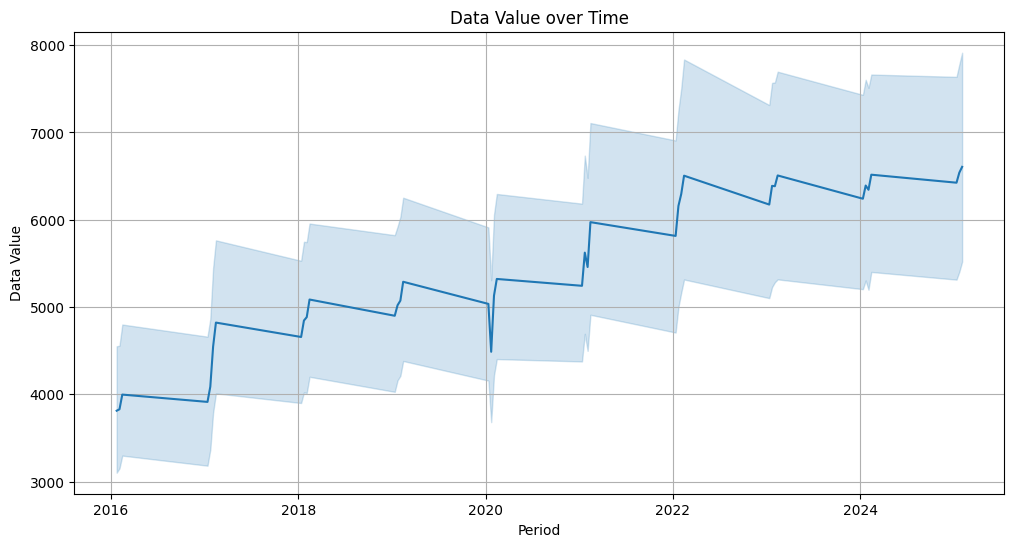

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(x="Period", y="Data_value", data=housing)
plt.title("Data Value over Time")
plt.xlabel("Period")
plt.ylabel("Data Value")
plt.grid(True)
plt.show()

In [15]:
corr_matrix = housing.corr(numeric_only=True)

print(corr_matrix["Data_value"].sort_values(ascending=False))

Data_value        1.000000
data_value_cat    0.727657
Period            0.103422
Magnitude              NaN
Series_title_5         NaN
Name: Data_value, dtype: float64


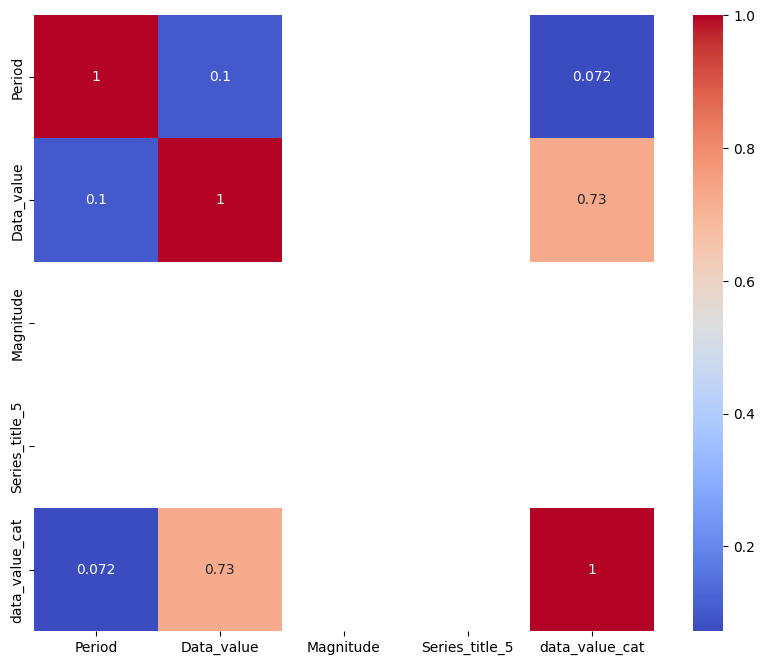

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.show()

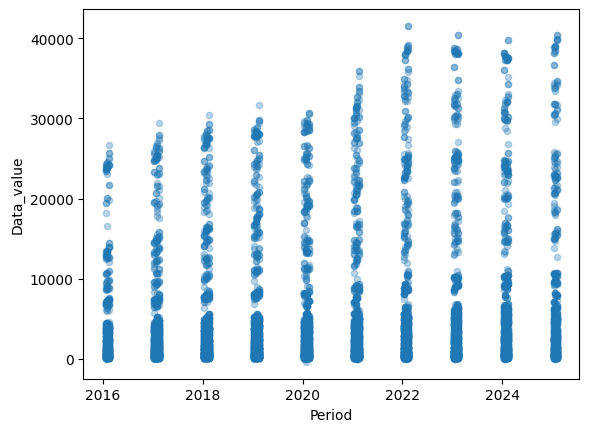

In [18]:
housing.plot(kind="scatter",
             x="Period",
             y="Data_value",
             alpha=0.3)

plt.show()

In [20]:
corr_matrix = housing.corr(numeric_only=True)

print(corr_matrix["Data_value"].sort_values(ascending=False))

Data_value        1.000000
data_value_cat    0.727657
Period            0.103422
Magnitude              NaN
Series_title_5         NaN
Name: Data_value, dtype: float64


In [22]:
corr_matrix = housing.corr(numeric_only=True)

print(corr_matrix["Data_value"].sort_values(ascending=False))

Data_value        1.000000
data_value_cat    0.727657
Period            0.103422
Magnitude              NaN
Series_title_5         NaN
Name: Data_value, dtype: float64


In [24]:
imputer = SimpleImputer(strategy="median")

housing_num = housing.select_dtypes(include=[np.number]).copy()

imputer.fit(housing_num)

housing_tr = imputer.transform(housing_num)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Series_title_5']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [26]:
housing_cat = housing[["STATUS"]]

encoder = OneHotEncoder()

housing_cat_encoded = encoder.fit_transform(housing_cat)

print(encoder.categories_)

[array(['F', 'R'], dtype=object)]


In [27]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, household_ix = 3,4,5,6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):

    def fit(self,X,y=None):
        return self

    def transform(self,X):
        rooms_per_household = X[:,rooms_ix]/X[:,household_ix]
        population_per_household = X[:,population_ix]/X[:,household_ix]

        return np.c_[X,rooms_per_household,population_per_household]

In [29]:
num_pipeline = Pipeline([
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
])

num_attribs = list(housing.select_dtypes(include=np.number).columns)
cat_attribs = ["STATUS"]

full_pipeline = ColumnTransformer([
        ("num",num_pipeline,num_attribs),
        ("cat",OneHotEncoder(),cat_attribs)
])

housing_prepared = full_pipeline.fit_transform(housing)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Series_title_5']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
